In [30]:
!pip install scanpy

In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 1. LOAD DATA

In [32]:
print("Loading data...")
adata = sc.datasets.pbmc3k()

Loading data...


In [33]:
# CONVERT TO PANDAS DATAFRAME
# We turn the sparse matrix into a dense DataFrame.
# Rows = Cells, Columns = Genes
df = pd.DataFrame(
    data=adata.X.toarray(),
    index=adata.obs_names,
    columns=adata.var_names
)

In [34]:
print(f"Initial Shape: {df.shape}")

Initial Shape: (2700, 32738)


## 2. FILTERING (Manual Data Cleaning)

In [35]:
# Filter Genes: Keep columns where count > 0 in at least 3 rows
genes_detected_count = (df > 0).sum(axis=0)
df = df.loc[:, genes_detected_count >= 3]

In [36]:
# Filter Cells: Keep rows where number of active genes >= 200
genes_per_cell = (df > 0).sum(axis=1)
df = df.loc[genes_per_cell >= 200, :]

In [37]:
# Filter Mitochondria:
# 1. Identify columns that start with "MT-"
mt_genes = [col for col in df.columns if col.startswith('MT-')]

In [38]:
# 2. Calculate sum of MT genes vs Total sum for each cell
mt_sum = df[mt_genes].sum(axis=1)
total_sum = df.sum(axis=1)
mt_percent = mt_sum / total_sum

In [39]:
# 3. Keep rows where MT% < 0.05 (5%)
df = df.loc[mt_percent < 0.05, :]

In [40]:
# Filter Doublets: Keep rows with < 2500 active genes
active_genes = (df > 0).sum(axis=1)
df = df.loc[active_genes < 2500, :]

In [41]:
print(f"Shape after Filtering: {df.shape}")

Shape after Filtering: (2638, 13714)


## 3. NORMALIZATION

In [42]:
# Normalize Total: Scale every row so it sums to 10,000
# Formula: (value / row_sum) * 10,000
row_sums = df.sum(axis=1)
df_norm = df.div(row_sums, axis=0) * 10000

In [43]:
# Log Transform: log(x + 1)
df_log = np.log1p(df_norm)

## 4. FEATURE SELECTION

In [44]:
# the top 2000 genes with the highest variance.
variances = df_log.var(axis=0)
top_2000_genes = variances.nlargest(2000).index
df_final = df_log[top_2000_genes]

print(f"Shape after Feature Selection: {df_final.shape}")

Shape after Feature Selection: (2638, 2000)


## 5. PCA (Dimensionality Reduction)

In [45]:
# Standardize features (mean=0, variance=1) before PCA
# This is standard ML practice.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final)

# Run PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Output Shape: {X_pca.shape}")

PCA Output Shape: (2638, 50)


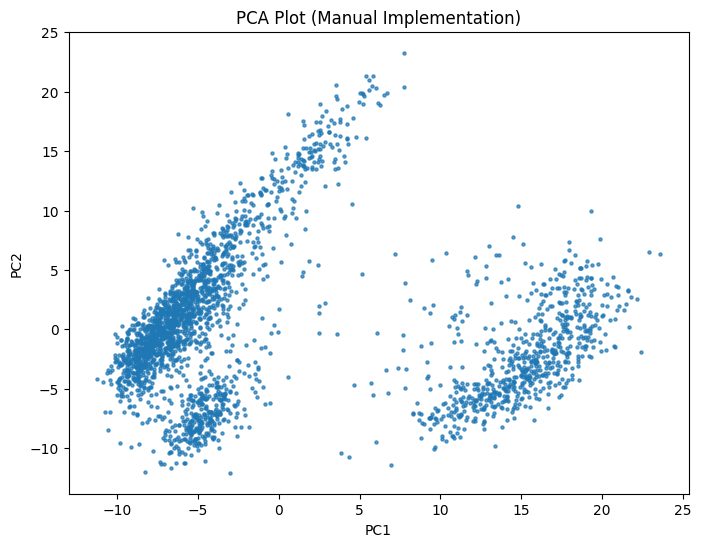

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.7)
plt.title("PCA Plot (Manual Implementation)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

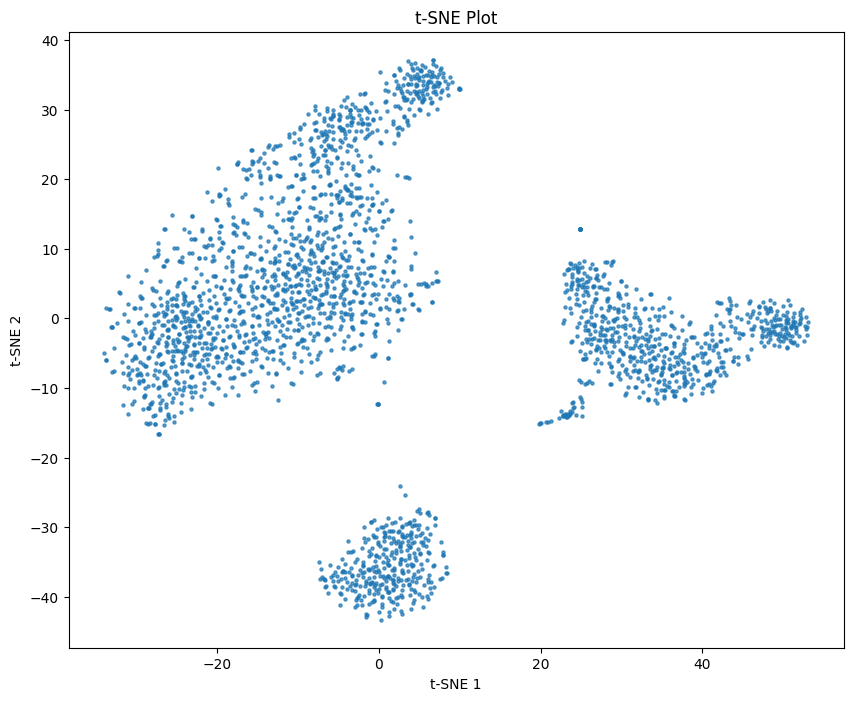

In [47]:
# Initialize and fit t-SNE
# We use the X_pca data because it's faster than using the raw data
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, alpha=0.7)
plt.title("t-SNE Plot")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## PHASE 2: CLUSTERING (Unsupervised Learning)

In [48]:
# 1. Run K-Means Clustering
# We use X_pca (50 dimensions) instead of raw data for better performance.
# We choose k=7 because PBMC datasets typically have ~7 major cell types.
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

print("Clustering Complete. Found 7 clusters.")

Clustering Complete. Found 7 clusters.


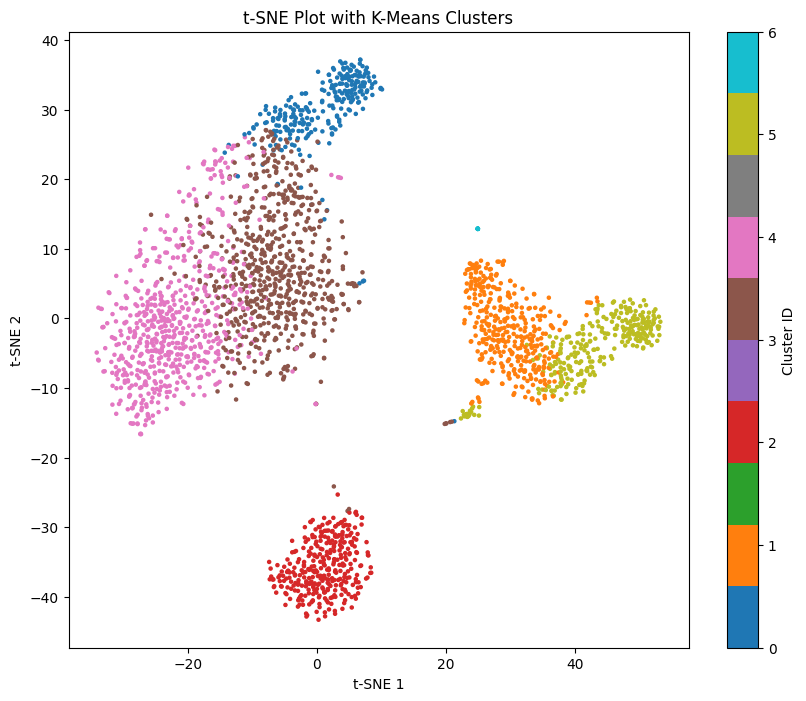

In [49]:
# 2. Visualize Clusters on t-SNE
# We plot the same t-SNE as before, but now we color points by 'cluster_labels'
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='tab10', s=5)
plt.title("t-SNE Plot with K-Means Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [50]:
# 3. Find Marker Genes (The "Biological Labeling")
# We need to know: "What makes Cluster 0 special?"
# We look for genes that have high values in Cluster 0 compared to everyone else.

# Create a temporary DataFrame combining gene data + cluster labels
# (Using df_final which has the top 2000 genes)
df_analysis = df_final.copy()
df_analysis['Cluster'] = cluster_labels

# Calculate the mean expression of every gene for every cluster
cluster_means = df_analysis.groupby('Cluster').mean()

print("\nTop Marker Genes per Cluster:")
# For each cluster, find the top 3 genes with the highest mean expression
markers = {}
for cluster_id in range(7):
    # Sort genes by mean expression in this cluster
    top_genes = cluster_means.loc[cluster_id].nlargest(3).index.tolist()
    markers[cluster_id] = top_genes
    print(f"Cluster {cluster_id}: {top_genes}")


Top Marker Genes per Cluster:
Cluster 0: ['MALAT1', 'NKG7', 'ACTB']
Cluster 1: ['FTL', 'FTH1', 'LYZ']
Cluster 2: ['MALAT1', 'CD74', 'RPL13']
Cluster 3: ['MALAT1', 'RPL13', 'RPS6']
Cluster 4: ['MALAT1', 'RPL13', 'RPS6']
Cluster 5: ['FTL', 'FTH1', 'ACTB']
Cluster 6: ['ACTB', 'GPX1', 'OAZ1']


## PHASE 3: CLASSIFICATION (Supervised Learning)

In [51]:
# Goal: Build a classifier that can predict the 'Cluster ID' (Cell Type)
# based on the gene expression profile.

# 1. Prepare Data
X = X_pca  # Features: The 50 Principal Components
y = cluster_labels # Target: The Cluster IDs we just found

In [52]:
# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# 3. Train Classifier (Support Vector Machine - SVM)
# SVM is excellent for high-dimensional biological data.
clf = SVC(kernel='linear', random_state=42)
clf.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [54]:
# 4. Evaluate Performance
accuracy = clf.score(X_test, y_test)
print(f"Classifier Accuracy on Test Set: {accuracy:.2f} ({accuracy*100:.1f}%)")

Classifier Accuracy on Test Set: 0.97 (97.2%)


In [55]:
# 5. Cross-Validation
# Splits data 5 different ways to ensure accuracy isn't a fluke.
cv_scores = cross_val_score(clf, X, y, cv=5)
print(f"5-Fold Cross-Validation Accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std()*2:.2f})")

5-Fold Cross-Validation Accuracy: 0.97 (+/- 0.01)


In [56]:
# 6. Analysis of Misclassification (Confusion Matrix)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

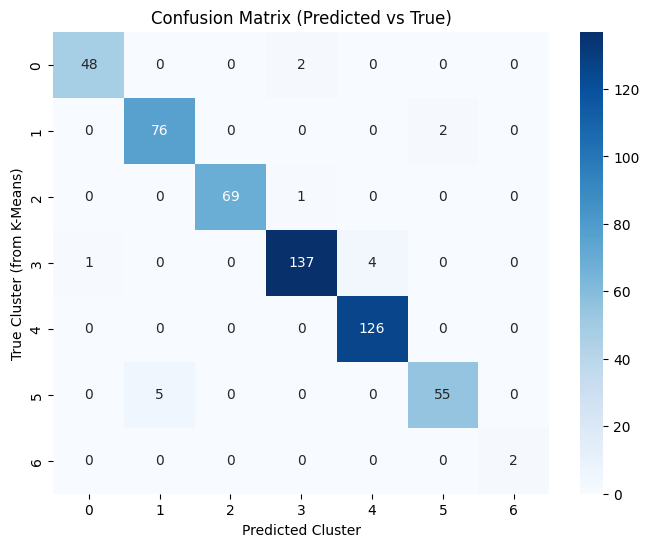


Assignment Completed.


In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Predicted vs True)")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Cluster (from K-Means)")
plt.show()

print("\nAssignment Completed.")